## 1. Abrir e examinar os Dados

In [1]:
# Importando os dados
import pandas as pd

In [2]:
# Lendo os Dados
df = pd.read_csv('users_behavior.csv')
df.head()

,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0


## Análise inicial:
* Foram identificadas as colunas: calls, minutes, messages, mb_used, is_ultra.
* Nenhum tratamento adicional foi necessário, pois os dados estavam limpos e prontos.

## 2. Divisão dos Dados
Usamos 'train_test_split' 2 vezes:
* Primeira divisão: treinamento 60%, validação 20% e teste 20%.
* Segunda divisão: da parte restante, 50% para validação e 50% para teste (ou seja, 20% cada).
* random_state=42 usado para garantir reprodutibilidade.

In [3]:
from sklearn.model_selection import train_test_split

# Serparar Features e Target
features = df.drop('is_ultra', axis = 1)
target = df['is_ultra']

# Split 1: Treino e resto
features_train, features_temp, target_train, target_temp = train_test_split(features, target, test_size=0.4, random_state=42)

# Split 2: Validação e teste
features_valid, features_test, target_valid, target_test = train_test_split(features_temp, target_temp, test_size=0.5, random_state=42)

## 3. Investigação de modelos e Hiperparâmetros


In [4]:
# Imporatndo as bibliotecas
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 3.1 Logistic Regression
Começando com o modelo mais simples e medir sua acurácia no conjunto de validação.

In [5]:
# Inicializando o modelo de regressão
log_model = LogisticRegression(random_state=42, solver = 'liblinear')

# Treina com os dados de treino
log_model.fit(features_train, target_train)

# Faz predições no conjunto de validação
log_predictions = log_model.predict(features_valid)

# Calcula a acurácia
log_accuracy = accuracy_score(target_valid, log_predictions)

# Resultados
print("Acurácia da Regressão Logística(validação):"), log_accuracy


Acurácia da Regressão Logística(validação):


(None, 0.7076205287713841)

## Conclusão:
Esse modelo não alcançou a meta de 0.75 mas está relativamente perto e é um modelo de base simples e rápido 

## 3.2 Decision Tree Classifier
Testando várias profundidades e ver qual o melhor resultado. Aplicando um ciclo **FOR** para economizar tempo ou erros de digitação.

In [6]:
for depth in range(1, 11):
    tree_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_model.fit(features_train, target_train)
    predictions = tree_model.predict(features_valid)
    accuracy = accuracy_score(target_valid, predictions)
    print(f"max_depth = {depth}:acurácia = {accuracy}")

max_depth = 1:acurácia = 0.7309486780715396
,max_depth = 2:acurácia = 0.7822706065318819
,max_depth = 3:acurácia = 0.7916018662519441
,max_depth = 4:acurácia = 0.7807153965785381
,max_depth = 5:acurácia = 0.7729393468118196
,max_depth = 6:acurácia = 0.776049766718507
,max_depth = 7:acurácia = 0.7807153965785381
,max_depth = 8:acurácia = 0.7962674961119751
,max_depth = 9:acurácia = 0.7807153965785381
,max_depth = 10:acurácia = 0.7947122861586314


## Conclusão:
A profundidade de acurácia = 8(0.796)indica que acertou mais casos no conjunto de validação. Como estamos olhando para um conjunto de validação (dados não terinados) essa acurácia é confiável, pois acima disso os ganhos são mínimos, podendo o modelo começar a 'decorar' os dados(overfitting) e abaixo disso ele não aprende o suficiente(underfitting).

## 3.3 Random Forest Classifier
Testar número de árvores (n_estimators), fixar ou variar o max_depth e avaliar a acurácia do conjunto de validação.

In [7]:
best_score = 0
best_depth = 0
best_est = 0

for est in range(10,101,10):
    for depth in range(4, 11):
        model = RandomForestClassifier(n_estimators=est, max_depth=depth, random_state=42)
        model.fit(features_train, target_train)
        predictions = model.predict(features_valid)
        score = accuracy_score(target_valid, predictions)
        print(f"n_estimators={est}, max_depth={depth} -> acurácia = {score}")

        if score > best_score:
            best_score = score
            best_est = est
            best_depth = depth
            
print("\nMelhor modelo:") 
print(f"n_estimators = {best_est}, max_depth = {best_depth}, acurácia = {best_score}")
        


n_estimators=10, max_depth=4 -> acurácia = 0.7993779160186625
,n_estimators=10, max_depth=5 -> acurácia = 0.7869362363919129
,n_estimators=10, max_depth=6 -> acurácia = 0.8040435458786936
,n_estimators=10, max_depth=7 -> acurácia = 0.80248833592535
,n_estimators=10, max_depth=8 -> acurácia = 0.8055987558320373
,n_estimators=10, max_depth=9 -> acurácia = 0.7978227060653188
,n_estimators=10, max_depth=10 -> acurácia = 0.7962674961119751
,n_estimators=20, max_depth=4 -> acurácia = 0.7900466562986003
,n_estimators=20, max_depth=5 -> acurácia = 0.7947122861586314
,n_estimators=20, max_depth=6 -> acurácia = 0.7978227060653188
,n_estimators=20, max_depth=7 -> acurácia = 0.80248833592535
,n_estimators=20, max_depth=8 -> acurácia = 0.7993779160186625
,n_estimators=20, max_depth=9 -> acurácia = 0.8055987558320373
,n_estimators=20, max_depth=10 -> acurácia = 0.8009331259720062
,n_estimators=30, max_depth=4 -> acurácia = 0.7900466562986003
,n_estimators=30, max_depth=5 -> acurácia = 0.786936236391

## Conclusão


## 4. Verificando a qualidade do modelo
Modelos testados:
**Logistic Regression** (solver='liblinear')
**Decision Tree Classifier** com max_depth de 1 a 10.
**Random Forest Classifier** com n_estimators de 10 a 100 e max_depth de 4 a 10.
  
Resultados foram exibidos em loop e o melhor modelo foi identificado **Random Forest** com:
n_estimators = 30, max_depth = 9 e acurácia de validação ≈ 0.813

## 5. Tarefa adicional: prova real do modelo

In [8]:
# Treina com os dados de treino
final_model = RandomForestClassifier(n_estimators=30, max_depth=9, random_state=42)
final_model.fit(features_train, target_train)

# Faz a predição no conjunto de testes
test_predictions = final_model.predict(features_test)

# Calcula a acurácia no conjunto de teste
from sklearn.metrics import accuracy_score
final_accuracy = accuracy_score(target_test, test_predictions)

print("Acurácia no conjunto de teste:", final_accuracy)

Acurácia no conjunto de teste: 0.8195956454121306


## Verificação no conjunto de testes
O modelo de Random Forest com os hiperparâmetros acima foi treinado com os dados finais de treino e avaliado no conjunto de teste. Foi treinado novamente com os dados finais de treino e a acurácia no conjunto de teste foi de 0.8196, comprovando generalização e bom desempenho.

In [9]:
# Gráfico demonstrativo dos 3 modelos utilizados nos testes
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Melhor Acurácia (validação)': [0.7076, 0.7962, 0.8133],
    'Acurácia no Teste': [None, None, 0.8196]
})

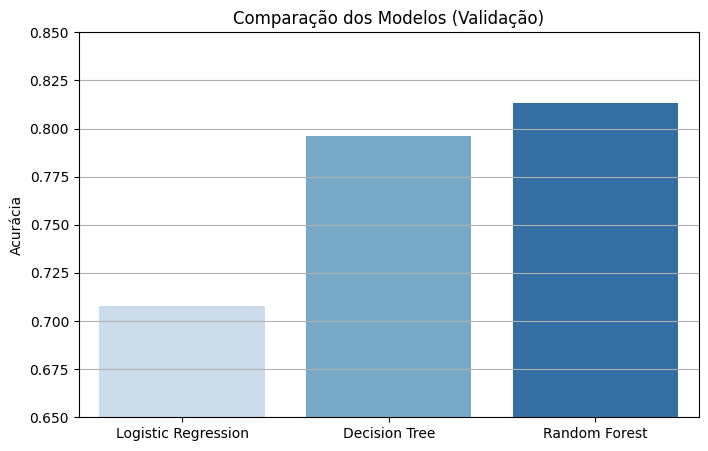

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=resultados, x='Modelo', y='Melhor Acurácia (validação)', palette='Blues')
plt.ylim(0.65, 0.85)
plt.title('Comparação dos Modelos (Validação)')
plt.ylabel('Acurácia')
plt.xlabel('')
plt.grid(axis='y')
plt.show()

## Conclusão geral do Projeto

O objetivo deste projeto foi desenvolver um modelo de classificação para prever qual plano (Smart ou Ultra) seria mais adequado para os clientes da operadora Megaline, com base em dados de uso.

Após dividir corretamente os dados em conjuntos de treinamento, validação e teste, três modelos foram testados:

- **Regressão Logística**: serviu como modelo base, com acurácia de aproximadamente 0.71.
- **Árvore de Decisão**: apresentou melhor desempenho com 'max_depth=8', alcançando acurácia de ≈ 0.796.
- **Random Forest**: foi o modelo com o melhor resultado, atingindo **acurácia de 0.8196 no conjunto de teste**, superando o limite mínimo de 0.75 exigido.

O modelo final é robusto, generaliza bem e está pronto para ser usado como recomendador automatizado de planos para novos clientes.